## 1. What this notebook computes

Notebook 18b proved the pairing theorems T1 and T2 as identities. This notebook
SEES them in numbers. It uses an exact family of solutions of the field equation
of dirac16complex00 (16 commuting complex components) in the author's metric: the
fields that depend on the time $x_4$ only. For such a field the 16 field equations
become 16 ordinary differential equations in $x_4$, which a computer can solve.

1. It solves one such field $\Psi$ (mass $m$, coupling $\lambda$) with the
   Runge-Kutta method and checks it against the exact formula of the Revision
   theory record.
2. **T1.** It solves, independently, the theory with $(-m, -\lambda)$ starting
   from $\Gamma\Psi(0)$, and finds exactly $\Gamma\Psi(x_4)$ at every time; it
   computes the charge density, the current and all 36 components of the
   energy-momentum tensor of both along the canonical deflating history
   $a_4 = AHx_4$ of the Revision record: they are exactly opposite.
3. **T2.** It solves, independently, the theory with $(-m, \lambda)$ on the
   mirror patch beyond the brane $z = \pi/2$, starting from
   $\gamma^{(x_8)}\Psi(0)$, and finds exactly $\gamma^{(x_8)}\Psi(x_4)$; the charge
   density and the energy density are EQUAL, the scalar $S$ is opposite.
4. **Spectra.** It shows that the evolution generators of a universe and of its
   partners have the same eigenvalues, and, for plane waves in flat 4+4 space (the
   quantum reading Q), it reproduces the one-particle samples of the Revision
   pairing record and shows how $\Gamma$ reverses every Krein norm while
   $\gamma^{(x_8)}$ keeps it.

Seven figures show the solutions, the partners, their densities and spectra.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 18c (T1 and T2 numerically: solutions, partners, currents and spectra) is the
file `Revision/textbook/notebooks/18c_pairs_numerically.ipynb` of the repository
Dirac_claude. It takes the exact family of solutions of the field equation of
dirac16complex00 in the author's metric that depend on the time x4 only (recorded in the
Revision theory reports), integrates one solution with the Runge-Kutta method and
compares it with the exact formula, and then solves its two partners independently: the
T1 partner with mass and coupling reversed, starting from Gamma times the initial value,
and the T2 partner on the mirror patch beyond the brane, starting from gamma^(x8) times
the initial value. It checks that the partners are exactly Gamma Psi and gamma^(x8) Psi,
that the T1 partner has the opposite charge density, current and energy-momentum tensor
(all 36 components, along the canonical deflating history a4 = A H x4), that the T2
partner has the same ones and the opposite scalar S, that the charge obeys its
conservation law, and that the spectra of the partners are equal. For the quantum reading
Q it reproduces the one-particle samples of the Revision pairing record (frequencies,
eigenspace dimensions, Krein inertia (4,4), the Krein-neutral imaginary and zero
frequencies) and shows that the chirality image reverses every Krein norm while the
mirror image keeps it. Seven teaching figures. It needs a computer with Windows 11, macOS
or Linux, an internet connection for the installation, the program Git, and Python 3.12
or newer (the notebooks were built with Python 3.14.5) with these packages at exactly
these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab
4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The
notebook itself imports numpy, sympy and matplotlib; the other packages run Jupyter, the
program that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 18c_pairs_numerically.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 30 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 18c_pairs_numerically.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
18c_pairs_numerically.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/18c.captions.json`
- `Revision/textbook/figures/18c_1_rk4_convergence.png`
- `Revision/textbook/figures/18c_2_partner_components.png`
- `Revision/textbook/figures/18c_3_t1_pair_densities.png`
- `Revision/textbook/figures/18c_4_t2_mirror_densities.png`
- `Revision/textbook/figures/18c_5_family_spectrum.png`
- `Revision/textbook/figures/18c_6_flat_dispersion.png`
- `Revision/textbook/figures/18c_7_krein_norms.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS every figure file of this notebook exists
    ALL 21 CHECKS PASSED (notebook 18c)

and the notebook must show 7 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/18c_pairs_numerically.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" for gammas.json or one of the reports: the notebook reads nine
  files of the repository; it must be opened inside the folder
  Revision/textbook/notebooks of a complete copy of the repository. Clone the repository
  again and open the notebook there.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 18c (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 18c (T1 and T2 numerically: solutions, partners, currents and spectra) is the
# file Revision/textbook/notebooks/18c_pairs_numerically.ipynb of the repository
# Dirac_claude. It takes the exact family of solutions of the field equation of
# dirac16complex00 in the author's metric that depend on the time x4 only (recorded in
# the Revision theory reports), integrates one solution with the Runge-Kutta method and
# compares it with the exact formula, and then solves its two partners independently: the
# T1 partner with mass and coupling reversed, starting from Gamma times the initial
# value, and the T2 partner on the mirror patch beyond the brane, starting from
# gamma^(x8) times the initial value. It checks that the partners are exactly Gamma Psi
# and gamma^(x8) Psi, that the T1 partner has the opposite charge density, current and
# energy-momentum tensor (all 36 components, along the canonical deflating history a4 = A
# H x4), that the T2 partner has the same ones and the opposite scalar S, that the charge
# obeys its conservation law, and that the spectra of the partners are equal. For the
# quantum reading Q it reproduces the one-particle samples of the Revision pairing record
# (frequencies, eigenspace dimensions, Krein inertia (4,4), the Krein-neutral imaginary
# and zero frequencies) and shows that the chirality image reverses every Krein norm
# while the mirror image keeps it. Seven teaching figures. It needs a computer with
# Windows 11, macOS or Linux, an internet connection for the installation, the program
# Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these
# packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib
# 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and
# nbconvert 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other
# packages run Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 18c_pairs_numerically.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 30
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 18c_pairs_numerically.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 18c_pairs_numerically.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/18c.captions.json
# - Revision/textbook/figures/18c_1_rk4_convergence.png
# - Revision/textbook/figures/18c_2_partner_components.png
# - Revision/textbook/figures/18c_3_t1_pair_densities.png
# - Revision/textbook/figures/18c_4_t2_mirror_densities.png
# - Revision/textbook/figures/18c_5_family_spectrum.png
# - Revision/textbook/figures/18c_6_flat_dispersion.png
# - Revision/textbook/figures/18c_7_krein_norms.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS every figure file of this notebook exists
#     ALL 21 CHECKS PASSED (notebook 18c)
#
# and the notebook must show 7 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/18c_pairs_numerically.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" for gammas.json or one of the reports: the notebook reads nine
#   files of the repository; it must be opened inside the folder
#   Revision/textbook/notebooks of a complete copy of the repository. Clone the
#   repository again and open the notebook there.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "18c"  # this notebook: chapter 18, example c


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 18c complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Ordinary differential equation (ODE)**: an equation for functions of ONE
  variable (here the time $x_4$) and their first derivatives.
- **Runge-Kutta method (RK4)**: a recipe that advances the solution of an ODE by
  a step $h$ using four evaluations of the right-hand side; its error after a fixed
  time shrinks like $h^4$ (*fourth order*).
- **Homogeneous field**: a field that does not depend on $x_1, x_2, x_3, x_5, x_6,
  x_7, x_8$, only on the time $x_4$.
- **Scalar** $S = \bar\Psi\Psi = \Psi^\dagger C\Psi$; **charge density**
  $J^{x_4} = \Psi^\dagger B\Psi$ with the Krein matrix $B = -iC\gamma^{(x_4)}$;
  **current** $J^\mu = -i\bar\Psi\gamma^\mu\Psi$ (the convention of the theory
  record, so that $J^{x_4}$ is the charge density).
- **Energy-momentum tensor** $T_{\mu\nu}$: 36 independent numbers at each point
  that say how much energy and momentum there is and how it flows; in the
  convention of the pairing record used here the energy density is
  $\rho = -T_{x_4x_4}$.
- **Deflating history**: $a_4 = AHx_4$ with $A = 1$ (the canonical choice of the
  Revision Kohn-Sham record): as $x_4$ grows, 3-space inflates by $e^{a_4}$ and
  the three extra times $x_5, x_6, x_7$ deflate by $e^{-a_4}$.
- **Patch, mirror patch, brane**: $z = 6Hx_8$ runs over the patch $0 < z <
  \pi/2$; the mirror patch $\pi/2 < z < \pi$ is its image under $z \to \pi - z$;
  the brane $z = \pi/2$ joins them (an ASSUMED construction).
- **Eigenvalue, eigenvector**: $Mu = wu$ with a number $w$ and a column $u \neq
  0$; the set of eigenvalues is the *spectrum* of $M$.
- **Similar matrices**: $N = PMP^{-1}$; they have the same spectrum.
- **Krein norm** of a column $u$: the real number $u^\dagger Bu$, which can be
  positive or negative because $B$ has eight eigenvalues $+1$ and eight $-1$.
- **Krein inertia** of a set of columns: how many independent directions have a
  positive and how many a negative Krein norm.

## 4. The physical and mathematical situation

**The field equation for homogeneous fields.** The field equation of both fields
is $\gamma^\mu D_\mu\Psi = (m + \lambda S)\Psi$. For a field that depends on $x_4$
only, every derivative except $\partial_4$ vanishes, $\gamma^{x_4} =
\gamma^{(x_4)}$ (the vielbein factor of $x_4$ is 1), and the spin connection
contributes $\gamma^\mu\Omega_\mu = 3H\gamma^{(x_8)}$ on the patch (the deflation
terms cancel). So the 16 field equations are EXACTLY

$$\gamma^{(x_4)}\frac{d\Psi}{dx_4} + 3H\gamma^{(x_8)}\Psi = (m + \lambda S)\Psi .$$

Multiply on the left by $-\gamma^{(x_4)}$ and use $(\gamma^{(x_4)})^2 = -1$:

$$\frac{d\Psi}{dx_4} = M\Psi,\qquad M = -\gamma^{(x_4)}\big((m + \lambda S) -
3H\gamma^{(x_8)}\big) = -(m + \lambda S)\gamma^{(x_4)} +
3H\gamma^{(x_4)}\gamma^{(x_8)} .$$

The Revision theory record proves that $S$ is constant along such a solution, so
$M$ is a constant matrix with $M^2 = \big(9H^2 - (m + \lambda S)^2\big)I_{16}$,
and the exact solution is

$$\Psi(x_4) = \cos(wx_4)\,\Psi(0) + \frac{\sin(wx_4)}{w}\,M\Psi(0),\qquad
w = \sqrt{(m + \lambda S)^2 - 9H^2}$$

when $(m + \lambda S)^2 > 9H^2$ (an oscillation; otherwise the cosine and sine
become cosh and sinh, a growth). The history $a_4$ does not enter this
equation, but it enters the energy-momentum tensor through the vielbein factors
$e^{\pm a_4}$ and the spin connection, as the figures will show. (The value
$3H\gamma^{(x_8)}$ belongs to the diagonal vielbein; $S$, $J^\mu$ and
$T_{\mu\nu}$, the quantities plotted here, do not depend on that choice.)

**The mirror patch.** On the mirror patch the hidden vielbein factor is
$-\cot z > 0$ and the spin connection term changes sign: $\gamma^\mu\Omega_\mu =
-3H\gamma^{(x_8)}$. The equation there is $d\Psi/dx_4 = -\gamma^{(x_4)}\big((m +
\lambda S) + 3H\gamma^{(x_8)}\big)\Psi$.

**What the theorems predict.** T1: if $\Psi$ solves the $(m, \lambda)$ equation,
$\Gamma\Psi$ solves the $(-m, -\lambda)$ equation, with $T \to -T$ and
$J \to -J$. T2: if $\Psi$ solves the $(m, \lambda)$ equation on the patch,
$\gamma^{(x_8)}\Psi$ (taken at the mirror point) solves the $(-m, \lambda)$
equation on the mirror patch, with $S \to -S$ and $T$, $J$ pulled back (the
components with one $x_8$ index change sign, all others are equal).

**Plane waves in flat 4+4 space.** For the quantum reading Q the Revision record
uses the one-particle matrix $h_m(k) = -im\gamma^{(x_4)} - \gamma^{(x_4)}
\sum_{a\neq x_4}k_a\gamma^{(a)}$ of a plane wave $e^{-iwx_4 + ik\cdot x}$; its
eigenvalues are the frequencies $w$, with $h_m^2 = (m^2 + k_1^2 + k_2^2 + k_3^2 +
k_8^2 - k_5^2 - k_6^2 - k_7^2)I_{16}$.

## 5. The matrices

The next cell imports numpy and sympy, defines the record helpers (`reproduces`
passes only when the notebook's own result holds AND every named check of the
named reports has the verdict PASS), reads the author's eight real gamma matrices
and builds $C$, $\Gamma$ and $B$ as numpy arrays of floating-point numbers
(whole numbers and $\pm i$, which floating-point numbers store exactly).

In [2]:
import numpy as np  # arrays, matrices, eigenvalues
import sympy as sp  # exact symbolic algebra for the spin connection

GAMMAS = "Revision/algebra/gammas.json"
PY = "Revision/pairing/reports/python-pairing.json"
WL = "Revision/pairing/reports/wolfram-pairing.json"
THEORY = "Revision/pairing/pairing-theory.json"
TH_PY = "Revision/theory/reports/python-field-theory.json"
TH_WL = "Revision/theory/reports/wolfram-field-theory.json"
SCOPE = "Revision/theory/reports/python-scope.json"
PARAMETERS = "Revision/kohn_sham/results/parameters.json"


def read_json(relative):
    """Read a JSON file of the repository (a Revision record)."""
    return json.loads(repository_file(relative).read_text(encoding="utf-8"))


RECORDS = {f: read_json(f) for f in (PY, WL, TH_PY, TH_WL, SCOPE)}


def recorded(report_file, name):
    """The recorded entry (verdict and detail) of the check name of a report."""
    for entry in RECORDS[report_file]["checks"]:
        if entry["name"] == name:
            return entry
    return {"verdict": "MISSING", "detail": ""}


def reproduces(condition, name, *sources):
    """check(condition, name), which also requires every named check of every
    source (report_file, [check names]) to have the recorded verdict PASS."""
    ok = all(recorded(f, n)["verdict"].upper() == "PASS"
             for f, names in sources for n in names)
    text = "; ".join(f"{f}, check {', '.join(names)}" for f, names in sources)
    check(condition and ok, name, record=text)


fixture = read_json(GAMMAS)
gamma = {a: np.array(fixture["gamma"][a - 1], dtype=float) for a in range(1, 9)}
ETA = {a: int(fixture["eta"][a - 1]) for a in range(1, 9)}
I16 = np.eye(16)
C = gamma[8] @ gamma[1] @ gamma[2] @ gamma[3]
Gamma = gamma[8] @ gamma[1] @ gamma[2] @ gamma[3] @ gamma[4] @ gamma[5] @ gamma[6] \
    @ gamma[7]
B = -1j * C @ gamma[4]  # the Krein matrix
check(all(np.array_equal(gamma[a] @ gamma[b] + gamma[b] @ gamma[a],
                         2.0 * (ETA[a] if a == b else 0) * I16)
          for a in range(1, 9) for b in range(1, 9))
      and np.array_equal(Gamma, np.diag([-1.0] * 8 + [1.0] * 8))
      and np.array_equal(B.conj().T, B),
      "eight real 16 x 16 gammas (Clifford relations), Gamma = diag(-I8, I8), "
      "B Hermitian")

PASS eight real 16 x 16 gammas (Clifford relations), Gamma = diag(-I8, I8), B Hermitian


## 6. The spin connection on the patch and on the mirror patch

For a diagonal vielbein $e^a{}_\mu = f_\mu\delta^a_\mu$ whose factors depend on
$x_4$ and $x_8$ only, the canonical spin connection has one simple formula: for
two different directions $a$ and $b$,

$$\omega_{a,ab} = \eta_{aa}\,\frac{\partial_bf_a}{f_b},\qquad
\omega_{a,ba} = -\omega_{a,ab},$$

and every other component is zero (the first index is the direction of the
derivative $D_a$). The next cell writes the author's factors $f_1 = f_2 = f_3 =
e^{a_4}\sin^{1/6}z$, $f_4 = 1$, $f_5 = f_6 = f_7 = e^{-a_4}\sin^{1/6}z$, $f_8 =
s_8\cot z$ ($s_8 = +1$ on the patch, $-1$ on the mirror patch) with sympy, lists
the nonzero components on the patch in the format of the sympy pairing report
($a_4'$ written `a4p`) and compares the list with the recorded one word for word.
It then computes $\gamma^\mu\Omega_\mu$ in the *divergence form* of the theory
record, $\gamma^\mu\Omega_\mu = \frac{1}{2\sqrt{|g|}}\sum_\mu\partial_\mu
\big(\sqrt{|g|}\gamma^{(\mu)}/f_\mu\big)$, on both patches: $+3H\gamma^{(x_8)}$
and $-3H\gamma^{(x_8)}$.

In [3]:
x4, z, H_sym = sp.symbols("x4 z H", real=True)
a4 = sp.Function("a4")(x4)
a4p = sp.Symbol("a4p")


def d(expr, b):
    """The derivative of a coefficient along the coordinate x_b (z = 6 H x8)."""
    if b == 4:
        return sp.diff(expr, x4)
    if b == 8:
        return 6 * H_sym * sp.diff(expr, z)
    return sp.Integer(0)


def factors(s8):
    s6 = sp.sin(z) ** sp.Rational(1, 6)
    f = {a: sp.exp(a4) * s6 for a in (1, 2, 3)}
    f.update({a: sp.exp(-a4) * s6 for a in (5, 6, 7)})
    f.update({4: sp.Integer(1), 8: s8 * sp.cot(z)})
    return f


def connection(s8):
    """{(mu, a, b) with a < b: omega_mu ab} for the diagonal vielbein."""
    f, om = factors(s8), {}
    for a in range(1, 9):
        for b in range(1, 9):
            if a != b:
                value = sp.simplify(ETA[a] * d(f[a], b) / f[b])
                if value != 0:  # omega_a,ab (or -omega_a,ba when b < a)
                    om[(a, a, b) if a < b else (a, b, a)] = (
                        value if a < b else -value)
    return dict(sorted(om.items()))


def short(expr):
    expr = sp.simplify(expr).subs(sp.Derivative(a4, x4), a4p)
    return expr.subs(a4, sp.Symbol("a4"))


patch_om, mirror_om = connection(1), connection(-1)
listing = "; ".join(f"omega_x{mu} x{a}x{b} = {short(v)}"
                    for (mu, a, b), v in patch_om.items())
say("patch: " + listing)
same = recorded(PY, "geometry.spin_connection_components")["detail"] == (
    "nonzero components (a < b): " + listing)
reproduces(len(patch_om) == 12 and same,
           "the formula gives the 12 recorded spin connection components",
           (PY, ["geometry.spin_connection_components"]))
flips = all(sp.simplify(mirror_om[k] + patch_om[k]) == 0 if 8 in k[1:]
            else sp.simplify(mirror_om[k] - patch_om[k]) == 0 for k in patch_om)
divergence = {}
for s8 in (1, -1):
    f = factors(s8)
    sqrtg = sp.simplify(sp.Mul(*f.values()))
    divergence[s8] = {mu: sp.simplify(d(sqrtg / f[mu], mu) / (2 * sqrtg))
                      for mu in range(1, 9)}
say(f"divergence form, patch: coefficient of gamma^(x8) = {divergence[1][8]}, of "
    f"gamma^(x4) = {divergence[1][4]}; mirror patch: {divergence[-1][8]}, "
    f"{divergence[-1][4]}")
reproduces(flips and divergence[1][8] == 3 * H_sym and divergence[-1][8] == -3 * H_sym
           and all(divergence[s][mu] == 0 for s in (1, -1) for mu in range(1, 8)),
           "gamma^mu Omega_mu = +3 H gamma^(x8) (patch), -3 H gamma^(x8) (mirror)",
           (TH_PY, ["gamma_mu_Omega_mu_equals_3H_gamma_x8",
                    "divergence_of_sqrtg_gamma"]),
           (TH_WL, ["gammaOmega_equals_3H_gamma_x8", "gammaOmega_divergence_form"]))

patch: omega_x1 x1x4 = a4p*exp(a4)*sin(z)**(1/6); omega_x1 x1x8 =
    H*exp(a4)*sin(z)**(1/6); omega_x2 x2x4 = a4p*exp(a4)*sin(z)**(1/6); omega_x2 x2x8 =
    H*exp(a4)*sin(z)**(1/6); omega_x3 x3x4 = a4p*exp(a4)*sin(z)**(1/6); omega_x3 x3x8 =
    H*exp(a4)*sin(z)**(1/6); omega_x5 x4x5 = -a4p*exp(-a4)*sin(z)**(1/6); omega_x5 x5x8 =
    -H*exp(-a4)*sin(z)**(1/6); omega_x6 x4x6 = -a4p*exp(-a4)*sin(z)**(1/6); omega_x6 x6x8
    = -H*exp(-a4)*sin(z)**(1/6); omega_x7 x4x7 = -a4p*exp(-a4)*sin(z)**(1/6); omega_x7
    x7x8 = -H*exp(-a4)*sin(z)**(1/6)
PASS the formula gives the 12 recorded spin connection components
     reproduces Revision/pairing/reports/python-pairing.json, check
    geometry.spin_connection_components
divergence form, patch: coefficient of gamma^(x8) = 3*H, of gamma^(x4) = 0; mirror patch:
    -3*H, 0
PASS gamma^mu Omega_mu = +3 H gamma^(x8) (patch), -3 H gamma^(x8) (mirror)
     reproduces Revision/theory/reports/python-field-theory.json, check
    gamma_mu_Omega_mu_equals_3H

The next cell fixes the numbers. The history is the canonical one of the Revision
Kohn-Sham record, $a_4 = AHx_4$ with $A = 1$ (read from
`Revision/kohn_sham/results/parameters.json`). The other values are an
ILLUSTRATION chosen by this notebook (the theorems hold for every value): units in
which $m = 1$, $H = 0.2$, $\lambda = 0.3$, the hidden angle $z_0 = \pi/4$ on the
patch (its mirror point is $3\pi/4$), and an initial value $\Psi(0)$ of 16
complex numbers drawn with the fixed seed 2026, weighted towards the eigenvalue
$+1$ of $C$ (so that $S = \Psi^\dagger C\Psi$ is clearly positive: $C$ is real and
symmetric with $C^2 = 1$, its projectors are $P_{C\pm} = \frac12(1 \pm C)$, and
$S = |P_{C+}\Psi|^2 - |P_{C-}\Psi|^2$), and scaled to length 1. With these values
$(m + \lambda S)^2 > 9H^2$, so the solution oscillates. The cell then turns
the spin connection into numerical $16 \times 16$ matrices
$\Omega_\mu = \sum_{a<b}\omega_{\mu ab}S^{ab}$ at any time $x_4$ and angle $z$,
and defines the curved gammas $\gamma^\mu = \gamma^{(\mu)}/f_\mu$ and
$\gamma_\mu = \eta_{\mu\mu}f_\mu\gamma^{(\mu)}$.

In [4]:
A_hist = read_json(PARAMETERS)["physics"]["historyA"]  # A = 1
m, H, lam = 1.0, 0.2, 0.3  # an illustration (units m = 1)
Z0 = np.pi / 4  # the patch point; the mirror point is pi - Z0
rng = np.random.default_rng(2026)
raw = rng.normal(size=16) + 1j * rng.normal(size=16)
P_C = 0.5 * (I16 + C)  # the projector on the eigenvalue +1 of C
psi0 = 2.0 * P_C @ raw + 0.5 * (I16 - P_C) @ raw  # mostly in the +1 part: S > 0
psi0 = psi0 / np.linalg.norm(psi0)  # length 1
S0 = float((psi0.conj() @ C @ psi0).real)  # S of the initial value
report("S of the initial value", f"{S0:.6f}")
report("m + lambda S", f"{m + lam * S0:.6f}")
report("3 H", f"{3 * H:.6f}")

S_AB = {(a, b): 0.5 * gamma[a] @ gamma[b] for a in range(1, 9) for b in range(1, 9)}
history = {sp.Derivative(a4, x4): A_hist * H_sym}  # a4' = A H


def numeric(table):
    """Turn the sympy components into functions of (x4, z) for this H and A."""
    out = {}
    for key, value in table.items():
        e = value.subs(history).subs(a4, A_hist * H_sym * x4).subs(H_sym, H)
        out[key] = sp.lambdify((x4, z), e, "numpy")
    return out


OMEGA = {1: numeric(patch_om), -1: numeric(mirror_om)}
FACTOR = {s8: {mu: sp.lambdify((x4, z), e.subs(a4, A_hist * H_sym * x4)
                               .subs(H_sym, H), "numpy")
               for mu, e in factors(s8).items()} for s8 in (1, -1)}


def geometry_at(t, zv, s8):
    """Numbers at the time t and angle zv: f, g, gamma^mu, gamma_mu, Omega_mu."""
    f = {mu: float(FACTOR[s8][mu](t, zv)) for mu in range(1, 9)}
    Om = {mu: np.zeros((16, 16)) for mu in range(1, 9)}
    for (mu, a, b), fn in OMEGA[s8].items():
        Om[mu] = Om[mu] + float(fn(t, zv)) * S_AB[a, b]
    return {"f": f, "g": {mu: ETA[mu] * f[mu] ** 2 for mu in f},
            "sqrtg": abs(np.prod(list(f.values()))),
            "up": {mu: gamma[mu] / f[mu] for mu in f},
            "down": {mu: ETA[mu] * f[mu] * gamma[mu] for mu in f}, "Om": Om}


for s8, zv in ((1, Z0), (-1, np.pi - Z0)):
    geo = geometry_at(1.3, zv, s8)
    total = sum(geo["up"][mu] @ geo["Om"][mu] for mu in range(1, 9))
    assert np.allclose(total, 3 * s8 * H * gamma[8], atol=1e-12)
check(abs(m + lam * S0) > 3 * H,
      "|m + lambda S| > 3 H: the solution and both partners oscillate")

RESULT S of the initial value = 0.897319
RESULT m + lambda S = 1.269196
RESULT 3 H = 0.600000
PASS |m + lambda S| > 3 H: the solution and both partners oscillate


## 7. The solution: Runge-Kutta against the exact formula

The next cell defines the right-hand side $M\Psi$ of the ODE (with $s_8 = +1$ on
the patch and $-1$ on the mirror patch), one RK4 step and an integrator that
returns the solution at every step, and the exact formula of section 4. It
integrates $\Psi$ from $x_4 = 0$ to $x_4 = 20$ with 2000 steps of length 0.01 and
checks: $S$ stays equal to $S(0)$; the RK4 solution agrees with the exact formula;
$M^2 = (9H^2 - (m + \lambda S)^2)I_{16}$. It repeats the integration with 250 to
4000 steps to measure the order of the method (the error should fall by
$2^4 = 16$ when the step is halved).

In [5]:
X_END = 20.0  # integrate from x4 = 0 to 20 (a4 from 0 to A H 20 = 4)


def generator(psi, mass, coup, s8):
    """The matrix M of d psi/dx4 = M psi (s8 = +1 patch, -1 mirror patch)."""
    S = (psi.conj() @ C @ psi).real
    return -gamma[4] @ ((mass + coup * S) * I16 - 3 * s8 * H * gamma[8])


def rk4(psi_start, mass, coup, s8, steps):
    """The RK4 solution at x4 = 0, h, 2h, ..., X_END (steps + 1 rows)."""
    h = X_END / steps
    out = np.empty((steps + 1, 16), dtype=complex)
    psi = psi_start.astype(complex)
    out[0] = psi
    for n in range(steps):
        k1 = generator(psi, mass, coup, s8) @ psi
        k2 = generator(psi + 0.5 * h * k1, mass, coup, s8) @ (psi + 0.5 * h * k1)
        k3 = generator(psi + 0.5 * h * k2, mass, coup, s8) @ (psi + 0.5 * h * k2)
        k4 = generator(psi + h * k3, mass, coup, s8) @ (psi + h * k3)
        psi = psi + h / 6.0 * (k1 + 2 * k2 + 2 * k3 + k4)
        out[n + 1] = psi
    return out


def exact(psi_start, mass, coup, s8, times):
    """The exact solution cos(w x4) psi(0) + sin(w x4)/w M psi(0)."""
    M = generator(psi_start, mass, coup, s8)
    S = (psi_start.conj() @ C @ psi_start).real
    w = np.sqrt((mass + coup * S) ** 2 - 9 * H ** 2)
    return (np.cos(w * times)[:, None] * psi_start[None, :]
            + (np.sin(w * times) / w)[:, None] * (M @ psi_start)[None, :])


STEPS = 2000
times = np.linspace(0.0, X_END, STEPS + 1)
psi = rk4(psi0, m, lam, 1, STEPS)  # the universe of mass m on the patch
S_t = np.einsum("ti,ij,tj->t", psi.conj(), C, psi).real
error = np.abs(psi - exact(psi0, m, lam, 1, times)).max()
M0 = generator(psi0, m, lam, 1)
square_ok = np.allclose(M0 @ M0, (9 * H ** 2 - (m + lam * S0) ** 2) * I16, atol=1e-13)
errors = {}
for n in (250, 500, 1000, 2000, 4000):
    sol = rk4(psi0, m, lam, 1, n)
    errors[n] = float(np.abs(sol[-1] - exact(psi0, m, lam, 1, np.array([X_END]))[0])
                      .max())
orders = [np.log2(errors[n] / errors[2 * n]) for n in (250, 500, 1000, 2000)]
say("RK4 error at x4 = 20 for 250, 500, 1000, 2000, 4000 steps: "
    + ", ".join(f"{errors[n]:.1e}" for n in errors))
say("measured orders: " + ", ".join(f"{p:.2f}" for p in orders))
report("largest RK4 error with 2000 steps (all times, all components)",
       f"{error:.1e}")
reproduces(np.abs(S_t - S0).max() < 1e-9 and error < 1e-7 and square_ok,
           "S is constant and RK4 equals the exact homogeneous solution (2000 steps)",
           (TH_PY, ["exact_nonlinear_homogeneous_solution"]),
           (TH_WL, ["exact_solution_nonlinear_homogeneous_C"]),
           (SCOPE, ["good_sector_x8_independent_modes_without_boundary_condition"]))
check(all(3.8 < p < 4.2 for p in orders), "RK4 is of fourth order here")

RK4 error at x4 = 20 for 250, 500, 1000, 2000, 4000 steps: 2.0e-05, 1.2e-06, 6.9e-08,
    4.3e-09, 2.6e-10
measured orders: 4.10, 4.06, 4.03, 4.01
RESULT largest RK4 error with 2000 steps (all times, all components) = 4.3e-09
PASS S is constant and RK4 equals the exact homogeneous solution (2000 steps)
     reproduces Revision/theory/reports/python-field-theory.json, check
    exact_nonlinear_homogeneous_solution; Revision/theory/reports/wolfram-field-
    theory.json, check exact_solution_nonlinear_homogeneous_C;
    Revision/theory/reports/python-scope.json, check
    good_sector_x8_independent_modes_without_boundary_condition
PASS RK4 is of fourth order here


The next cell draws the convergence of the method: the error at $x_4 = 20$
against the step length on logarithmic axes, with a line of slope 4 for
comparison.

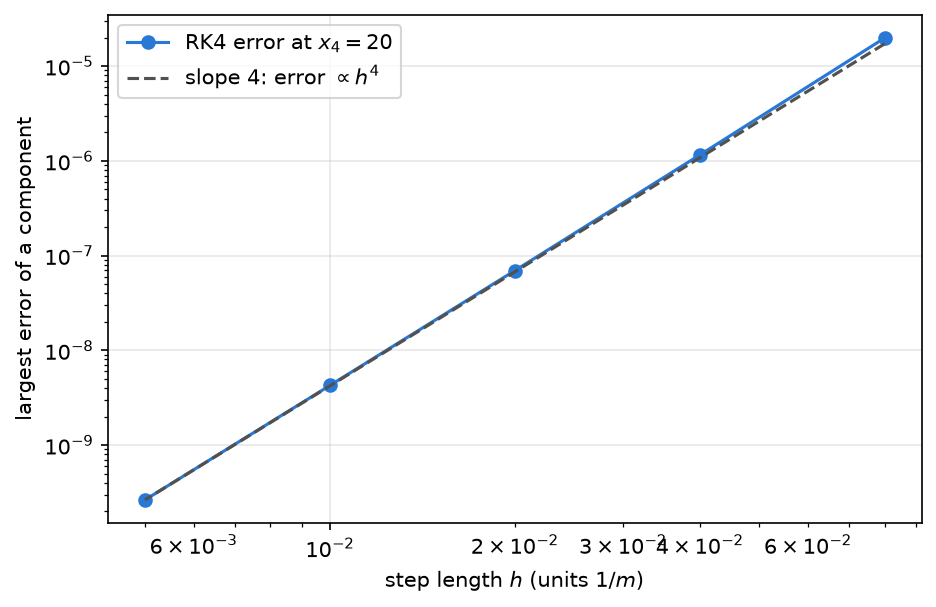

Figure 18c.1 saved as Revision/textbook/figures/18c_1_rk4_convergence.png


In [6]:
steps_list = sorted(errors)
hs = np.array([X_END / n for n in steps_list])
errs = np.array([errors[n] for n in steps_list])
fig, ax = plt.subplots(figsize=(7.0, 4.4))
ax.loglog(hs, errs, "o-", color="#2a78d6", label="RK4 error at $x_4 = 20$")
ax.loglog(hs, errs[-1] * (hs / hs[-1]) ** 4, "--", color="#52514e",
          label="slope 4: error $\\propto h^4$")
ax.set_xlabel("step length $h$ (units $1/m$)")
ax.set_ylabel("largest error of a component")
ax.legend()
save_figure(fig, "rk4_convergence",
            "Accuracy of the Runge-Kutta solution of the homogeneous field equation "
            "in the author's metric: the largest difference between a component of "
            "the computed field and of the exact solution of the Revision theory "
            "record at the time $x_4 = 20$ (vertical axis, logarithmic), against "
            "the step length $h$ in units of $1/m$ (horizontal axis, logarithmic), "
            "for 250 to 4000 steps. The points follow the dashed line of slope 4: "
            "halving the step divides the error by 16, the fourth order of the "
            "method. With 2000 steps the error is far below every difference "
            "studied in this notebook.")

## 8. Theorem T1 in numbers

The next cell solves, INDEPENDENTLY, the theory with $(-m, -\lambda)$ on the patch,
starting from $\Gamma\Psi(0)$, and compares the result $\Phi(x_4)$ with
$\Gamma\Psi(x_4)$ at all 2001 times. Since $\Gamma = \mathrm{diag}(-I_8, I_8)$,
T1 predicts $\Phi_A = -\Psi_A$ for the components $A = 1, \dots, 8$ and
$\Phi_A = +\Psi_A$ for $A = 9, \dots, 16$. As a negative control the cell also
solves the WRONG partner theory $(-m, +\lambda)$ from the same start, which must
NOT give $\Gamma\Psi$: the coupling has to change sign together with the mass.

In [7]:
phi = rk4(Gamma @ psi0, -m, -lam, 1, STEPS)  # the T1 partner, solved on its own
t1_gap = np.abs(phi - psi @ Gamma.T).max()  # row by row: Gamma psi(x4)
wrong = rk4(Gamma @ psi0, -m, lam, 1, STEPS)  # the negative control (-m, +lambda)
wrong_gap = np.abs(wrong - psi @ Gamma.T).max()
report("largest difference of the wrong partner (-m, +lambda) from Gamma Psi",
       f"{wrong_gap:.3f}")
check(t1_gap < 1e-12, "T1: the (-m, -lambda) solution from Gamma Psi(0) is Gamma "
      "Psi(x4) at all 2001 times (difference below 1e-12)")
check(wrong_gap > 0.1, "negative control: the (-m, +lambda) solution from Gamma "
      "Psi(0) is not Gamma Psi(x4)")

RESULT largest difference of the wrong partner (-m, +lambda) from Gamma Psi = 1.641
PASS T1: the (-m, -lambda) solution from Gamma Psi(0) is Gamma Psi(x4) at all 2001 times
    (difference below 1e-12)
PASS negative control: the (-m, +lambda) solution from Gamma Psi(0) is not Gamma Psi(x4)


The next cell draws two components: $A = 1$ (in the first half, where $\Gamma =
-1$) and $A = 9$ (in the second half, where $\Gamma = +1$), real parts, for the
field $\Psi$ (lines) and for its independently computed partner $\Phi$ (dots).

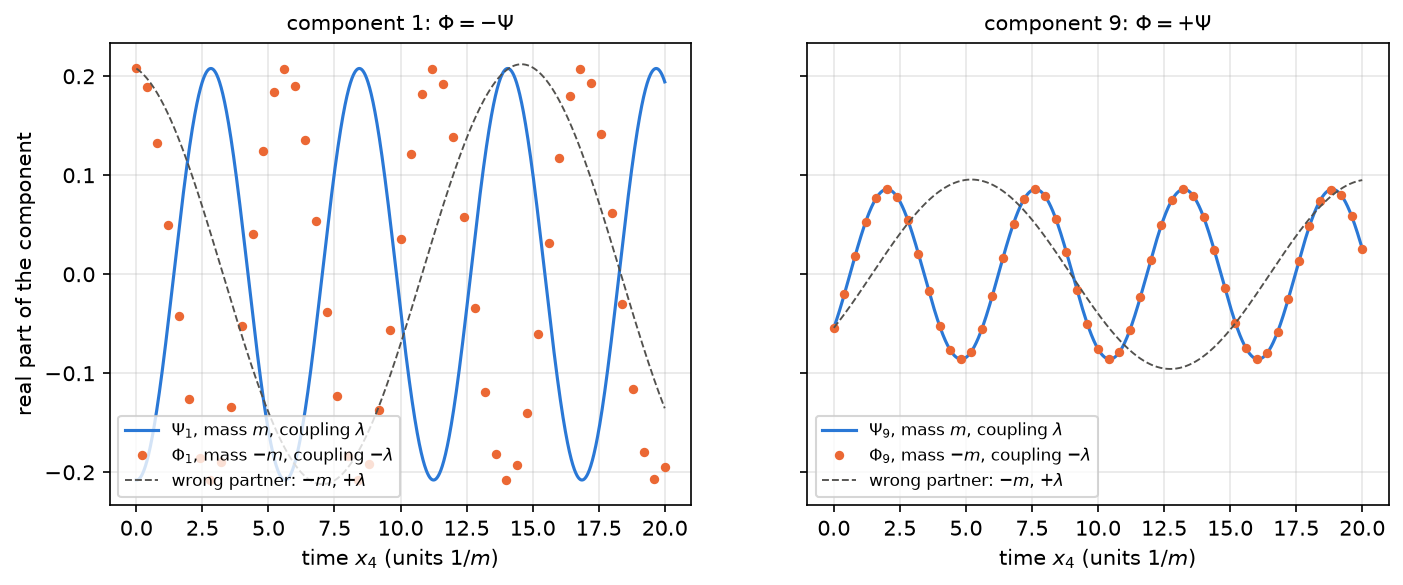

Figure 18c.2 saved as Revision/textbook/figures/18c_2_partner_components.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0), sharey=True)
every = slice(0, STEPS + 1, 40)  # a dot every 40 steps
for ax, A in zip(axes, (0, 8)):
    ax.plot(times, psi[:, A].real, color="#2a78d6",
            label=f"$\\Psi_{{{A + 1}}}$, mass $m$, coupling $\\lambda$")
    ax.plot(times[every], phi[every, A].real, "o", color="#eb6834", markersize=3.5,
            label=f"$\\Phi_{{{A + 1}}}$, mass $-m$, coupling $-\\lambda$")
    ax.plot(times, wrong[:, A].real, "--", color="#52514e", linewidth=0.9,
            label="wrong partner: $-m$, $+\\lambda$")
    ax.set_xlabel("time $x_4$ (units $1/m$)")
    ax.set_title(f"component {A + 1}: " + ("$\\Phi = -\\Psi$" if A < 8
                                            else "$\\Phi = +\\Psi$"), fontsize=10)
    ax.legend(loc="lower left", fontsize=8)
axes[0].set_ylabel("real part of the component")
save_figure(fig, "partner_components",
            "A solution and its T1 partner, computed separately. Lines: the real "
            "part of component 1 (left) and component 9 (right) of the homogeneous "
            "solution $\\Psi$ with mass $m = 1$ and coupling $\\lambda = 0.3$, "
            "against the time $x_4$ in units of $1/m$. Dots: the same components "
            "of the solution $\\Phi$ of the theory with $-m$ and $-\\lambda$, "
            "started from $\\Gamma\\Psi(0)$ and integrated on its own. In the first "
            "half of the components $\\Phi = -\\Psi$, in the second half "
            "$\\Phi = +\\Psi$: the partner is exactly $\\Gamma\\Psi$ at every time, "
            "as theorem T1 says. Dashed: the negative control with $-m$ and "
            "$+\\lambda$, which drifts away because it oscillates with another "
            "frequency.")

The next cell computes, at every 20th time, the bilinears of a field in the
geometry of the point $(x_4, z)$: $S$; the current $J^\mu = -i\bar\Psi\gamma^\mu
\Psi$ (8 components); and the energy-momentum tensor of the pairing record,

$$T_{\mu\nu} = \tfrac14\big(\bar\Psi\gamma_\mu D_\nu\Psi + \bar\Psi\gamma_\nu
D_\mu\Psi - (D_\mu\bar\Psi)\gamma_\nu\Psi - (D_\nu\bar\Psi)\gamma_\mu\Psi\big) -
g_{\mu\nu}\mathcal{L}/\sqrt{|g|},$$

with $D_4\Psi = d\Psi/dx_4 = M\Psi$ (the field equation), $D_\mu\Psi =
\Omega_\mu\Psi$ for the other directions (the field does not depend on them; the
spin connection still acts), $D_\mu\bar\Psi = (D_\mu\Psi)^\dagger C$, and
$\mathcal{L}/\sqrt{|g|} = \frac12\sum_\mu(\bar\Psi\gamma^\mu D_\mu\Psi -
(D_\mu\bar\Psi)\gamma^\mu\Psi) - mS - \frac{\lambda}{2}S^2$. The history
$a_4 = AHx_4$ enters through the factors $f_\mu$ and $\Omega_\mu$. The cell then
checks, at all sampled times, that the T1 partner has $J^\mu[\Phi] = -J^\mu[\Psi]$
for all 8 components and $T_{\mu\nu}[\Phi; -m, -\lambda] =
-T_{\mu\nu}[\Psi; m, \lambda]$ for all 36 components.

In [9]:
def bilinears(field, mass, coup, t, zv, s8):
    """S, J^mu (8 numbers) and T_mu nu (8 x 8) of a homogeneous field at (t, zv)."""
    geo = geometry_at(t, zv, s8)
    D = {mu: geo["Om"][mu] @ field for mu in range(1, 9)}
    D[4] = D[4] + generator(field, mass, coup, s8) @ field  # d field / dx4
    bar = field.conj() @ C  # the adjoint row Psibar = Psi^dagger C
    Dbar = {mu: D[mu].conj() @ C for mu in range(1, 9)}
    S = (bar @ field).real
    L = 0.5 * sum(bar @ geo["up"][mu] @ D[mu] - Dbar[mu] @ geo["up"][mu] @ field
                  for mu in range(1, 9)) - mass * S - 0.5 * coup * S ** 2
    T = np.zeros((8, 8), dtype=complex)
    for mu in range(1, 9):
        for nu in range(1, 9):
            T[mu - 1, nu - 1] = 0.25 * (
                bar @ geo["down"][mu] @ D[nu] + bar @ geo["down"][nu] @ D[mu]
                - Dbar[mu] @ geo["down"][nu] @ field
                - Dbar[nu] @ geo["down"][mu] @ field)
            if mu == nu:
                T[mu - 1, nu - 1] -= geo["g"][mu] * L
    J = np.array([-1j * bar @ geo["up"][mu] @ field for mu in range(1, 9)])
    assert np.abs(T.imag).max() < 1e-12 and np.abs(J.imag).max() < 1e-12
    return S, J.real, T.real


SAMPLE = range(0, STEPS + 1, 20)  # 101 sampled times
sampled = times[list(SAMPLE)]
data = {"psi": [bilinears(psi[n], m, lam, times[n], Z0, 1) for n in SAMPLE],
        "phi": [bilinears(phi[n], -m, -lam, times[n], Z0, 1) for n in SAMPLE]}
scale_T = max(np.abs(T).max() for _, _, T in data["psi"])
scale_J = max(np.abs(J).max() for _, J, _ in data["psi"])
t1_T = max(np.abs(Tp + Tq).max() for (_, _, Tp), (_, _, Tq)
           in zip(data["psi"], data["phi"])) / scale_T
t1_J = max(np.abs(Jp + Jq).max() for (_, Jp, _), (_, Jq, _)
           in zip(data["psi"], data["phi"])) / scale_J
t1_S = max(abs(Sp - Sq) for (Sp, _, _), (Sq, _, _) in zip(data["psi"], data["phi"]))
reproduces(t1_T < 1e-12 and t1_J < 1e-12 and t1_S < 1e-12,
           "T1: S kept, J -> -J (8) and T -> -T (36) at all 101 sampled times",
           (PY, ["T1.metric.commuting.emt", "T1.metric.commuting.current"]))

PASS T1: S kept, J -> -J (8) and T -> -T (36) at all 101 sampled times
     reproduces Revision/pairing/reports/python-pairing.json, check
    T1.metric.commuting.emt, T1.metric.commuting.current


The next cell checks three facts of the theory record about homogeneous solutions,
at all sampled times: the energy density is $\rho = -T_{x_4x_4} = mS +
\frac{\lambda}{2}S^2$; the three kinds of pressure $p_\mu = -g^{\mu\mu}T_{\mu\mu}$
(3-space, extra times, hidden direction) all equal $\frac{\lambda}{2}S^2$; and the
mixed component $T_{x_4x_8}$ vanishes. It also checks the conservation of the
charge: the charge density can change in time only by flowing along the hidden
direction, $\partial_4J^{x_4} + \frac{1}{\sqrt{|g|}}\partial_8(\sqrt{|g|}J^{x_8}) =
0$; for a homogeneous field $J^{x_8} = \tan z\,Q$ with $Q = -i\bar\Psi
\gamma^{(x_8)}\Psi$ and $\sqrt{|g|} = \cos z$, so the law reads $\partial_4
J^{x_4} = -6HQ$, where $\partial_4J^{x_4} = 2\,\mathrm{Re}(\Psi^\dagger BM\Psi)$
follows from the field equation.

In [10]:
rho_ok = p_ok = mixed_ok = flow_ok = True
for n, (S, J, T) in zip(SAMPLE, data["psi"]):
    geo = geometry_at(times[n], Z0, 1)
    rho_ok = rho_ok and abs(-T[3, 3] - (m * S + 0.5 * lam * S ** 2)) < 1e-12
    p = [-T[mu - 1, mu - 1] / geo["g"][mu] for mu in (1, 2, 3, 5, 6, 7, 8)]
    p_ok = p_ok and max(abs(x - 0.5 * lam * S ** 2) for x in p) < 1e-12
    mixed_ok = mixed_ok and abs(T[3, 7]) < 1e-12 * scale_T
    field = psi[n]
    dJ4 = 2 * (field.conj() @ B @ generator(field, m, lam, 1) @ field).real
    Q = (-1j * field.conj() @ C @ gamma[8] @ field).real
    flow_ok = flow_ok and abs(dJ4 + 6 * H * Q) < 1e-12
reproduces(rho_ok and p_ok and mixed_ok,
           "rho = m S + (l/2) S^2, all pressures (l/2) S^2, T_x4x8 = 0 (homogeneous)",
           (TH_PY, ["commuting_homogeneous_on_shell_rho_p",
                    "commuting_T_x4x8_homogeneous"]))
reproduces(flow_ok, "the charge is conserved: d4 J^x4 = -6 H Q (flow along x8)",
           (TH_PY, ["commuting_current_conservation"]))

PASS rho = m S + (l/2) S^2, all pressures (l/2) S^2, T_x4x8 = 0 (homogeneous)
     reproduces Revision/theory/reports/python-field-theory.json, check
    commuting_homogeneous_on_shell_rho_p, commuting_T_x4x8_homogeneous
PASS the charge is conserved: d4 J^x4 = -6 H Q (flow along x8)
     reproduces Revision/theory/reports/python-field-theory.json, check
    commuting_current_conservation


The next cell draws the pair of T1 in three panels, against the time $x_4$:
the charge density $J^{x_4}$, the energy density $\rho = -T_{x_4x_4}$, and the
mixed component $T_{x_4x_1}$ (a flow of momentum along the inflating direction
$x_1$, which contains the spin connection and the factor $e^{a_4}$ of the
deflating history). Each panel shows the field, its T1 partner and their sum.

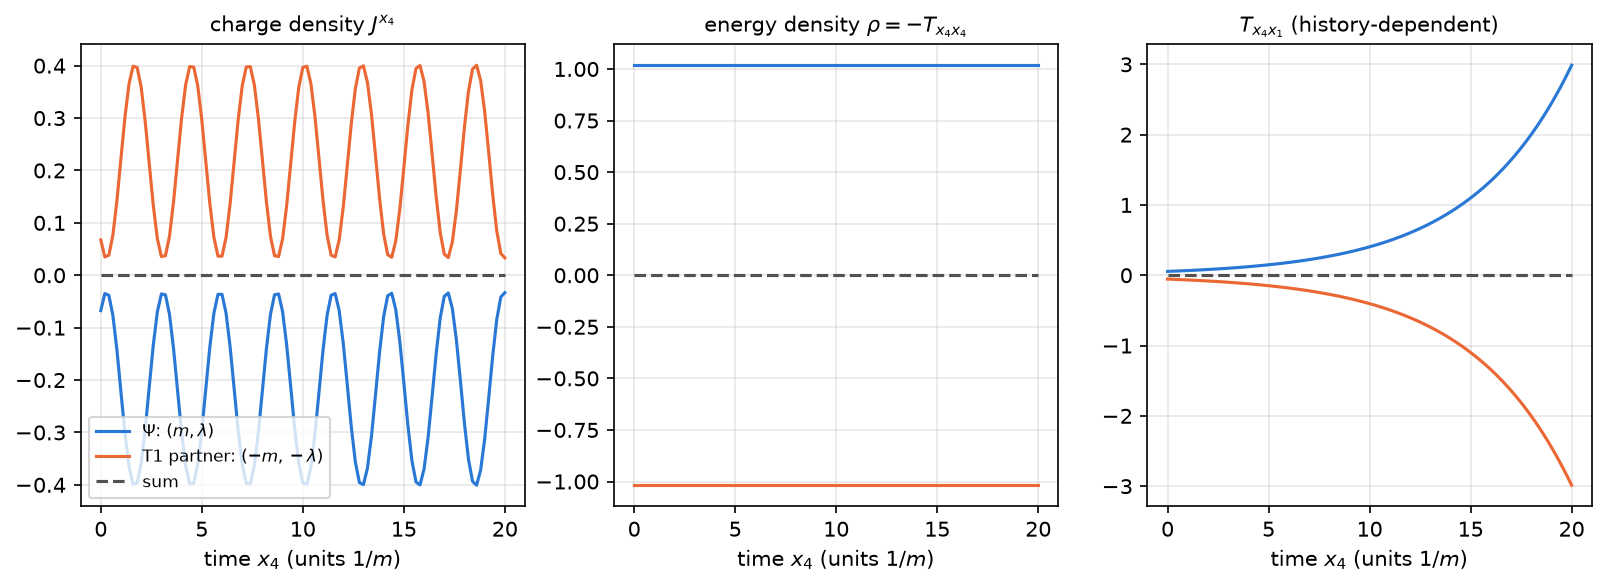

Figure 18c.3 saved as Revision/textbook/figures/18c_3_t1_pair_densities.png


In [11]:
def series(name, pick):
    return np.array([pick(S, J, T) for S, J, T in data[name]])


panels = [("charge density $J^{x_4}$", lambda S, J, T: J[3]),
          ("energy density $\\rho = -T_{x_4x_4}$", lambda S, J, T: -T[3, 3]),
          ("$T_{x_4x_1}$ (history-dependent)", lambda S, J, T: T[3, 0])]
fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.0))
for ax, (title, pick) in zip(axes, panels):
    a, b = series("psi", pick), series("phi", pick)
    ax.plot(sampled, a, color="#2a78d6", label="$\\Psi$: $(m, \\lambda)$")
    ax.plot(sampled, b, color="#eb6834", label="T1 partner: $(-m, -\\lambda)$")
    ax.plot(sampled, a + b, color="#52514e", linestyle="--", label="sum")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("time $x_4$ (units $1/m$)")
axes[0].legend(fontsize=8, loc="lower left")
save_figure(fig, "t1_pair_densities",
            "The T1 pair in numbers, along the deflating history $a_4 = AHx_4$ "
            "($A = 1$, $H = 0.2$, $m = 1$, $\\lambda = 0.3$, at $z = \\pi/4$). "
            "Horizontal axes: the time $x_4$ in units of $1/m$. Left: the charge "
            "density $J^{x_4}$; middle: the energy density $\\rho$; right: the "
            "mixed component $T_{x_4x_1}$, which grows with the factor $e^{a_4}$ "
            "of the inflating direction. Blue: the solution with $(m, \\lambda)$; "
            "orange: its partner $\\Gamma\\Psi$ with $(-m, -\\lambda)$; dashed: "
            "their sum. Every orange curve is the mirror image of the blue one in "
            "the horizontal axis, and the sum is zero at every time: the pair has "
            "zero total charge and energy-momentum as classical bilinears.")

## 9. Theorem T2 in numbers: the mirror partner

The next cell solves, INDEPENDENTLY, the theory with $(-m, \lambda)$ on the mirror
patch (the spin connection term is $-3H\gamma^{(x_8)}$ there), starting from
$\gamma^{(x_8)}\Psi(0)$, and compares the result $X(x_4)$ with
$\gamma^{(x_8)}\Psi(x_4)$. Then it computes the bilinears of $X$ at the mirror
point $z = \pi - z_0$ and checks the T2 predictions at all sampled times:
$S[X] = -S[\Psi]$; $J^\mu[X] = \Lambda_\mu J^\mu[\Psi]$ and $T_{\mu\nu}[X] =
\Lambda_\mu\Lambda_\nu T_{\mu\nu}[\Psi]$ with $\Lambda = \mathrm{diag}(1, 1, 1, 1,
1, 1, 1, -1)$ (only the components with an $x_8$ index change sign; the charge
density and the energy density are EQUAL).

In [12]:
chi = rk4(gamma[8] @ psi0, -m, lam, -1, STEPS)  # the mirror partner, on its own
t2_gap = np.abs(chi - psi @ gamma[8].T).max()
data["chi"] = [bilinears(chi[n], -m, lam, times[n], np.pi - Z0, -1) for n in SAMPLE]
LAM = np.array([1, 1, 1, 1, 1, 1, 1, -1], dtype=float)
t2_S = max(abs(Sp + Sx) for (Sp, _, _), (Sx, _, _) in zip(data["psi"], data["chi"]))
t2_J = max(np.abs(Jx - LAM * Jp).max() for (_, Jp, _), (_, Jx, _)
           in zip(data["psi"], data["chi"])) / scale_J
t2_T = max(np.abs(Tx - np.outer(LAM, LAM) * Tp).max() for (_, _, Tp), (_, _, Tx)
           in zip(data["psi"], data["chi"])) / scale_T
check(t2_gap < 1e-12, "T2: the (-m, lambda) mirror solution from gamma^(x8) Psi(0) "
      "is gamma^(x8) Psi(x4) at all 2001 times")
reproduces(t2_S < 1e-12 and t2_J < 1e-12 and t2_T < 1e-12,
           "T2: S -> -S, J and T pulled back (charge and energy density equal)",
           (PY, ["T2.metric.commuting.S_odd", "T2.metric.commuting.emt",
                 "T2.metric.commuting.current"]))

PASS T2: the (-m, lambda) mirror solution from gamma^(x8) Psi(0) is gamma^(x8) Psi(x4) at
    all 2001 times
PASS T2: S -> -S, J and T pulled back (charge and energy density equal)
     reproduces Revision/pairing/reports/python-pairing.json, check
    T2.metric.commuting.S_odd, T2.metric.commuting.emt, T2.metric.commuting.current


The next cell draws the T2 pair: the scalar $S$, the charge density $J^{x_4}$ and
the mixed component $T_{x_4x_1}$ of the field on the patch and of its mirror
partner on the mirror patch.

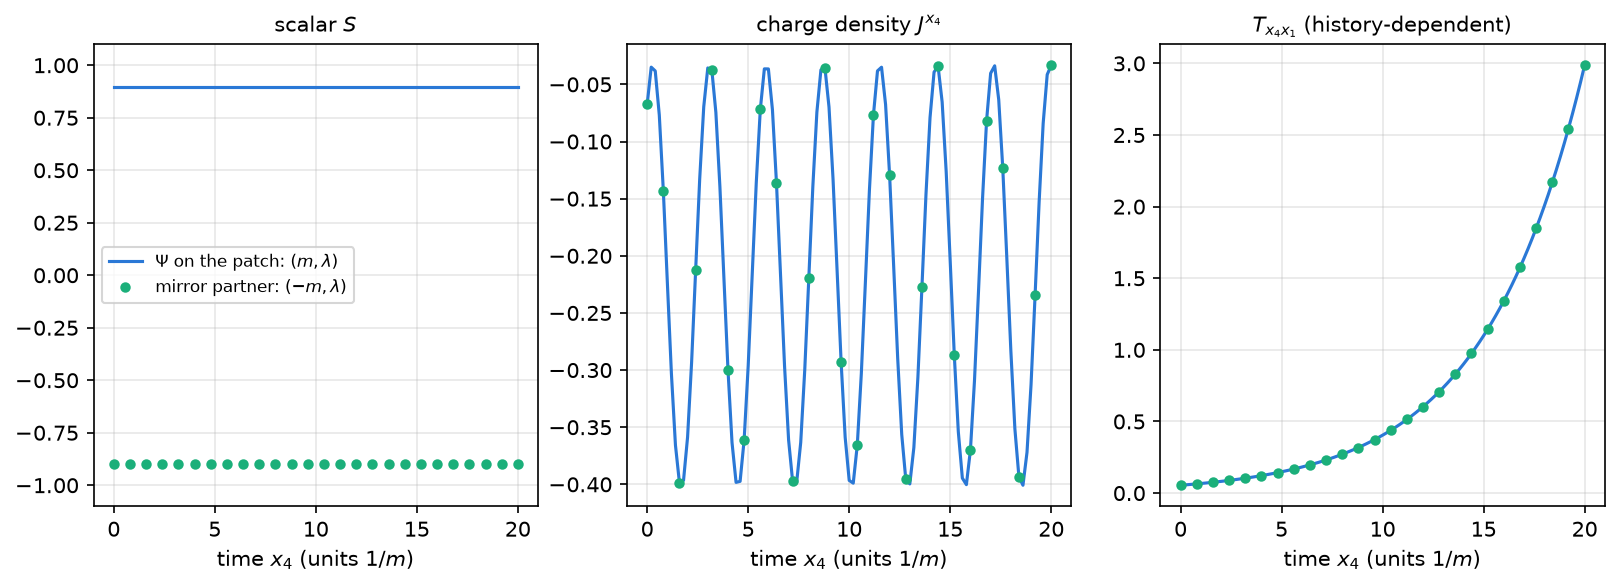

Figure 18c.4 saved as Revision/textbook/figures/18c_4_t2_mirror_densities.png


In [13]:
panels = [("scalar $S$", lambda S, J, T: S),
          ("charge density $J^{x_4}$", lambda S, J, T: J[3]),
          ("$T_{x_4x_1}$ (history-dependent)", lambda S, J, T: T[3, 0])]
fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.0))
for ax, (title, pick) in zip(axes, panels):
    ax.plot(sampled, series("psi", pick), color="#2a78d6",
            label="$\\Psi$ on the patch: $(m, \\lambda)$")
    ax.plot(sampled[::4], series("chi", pick)[::4], "o", color="#1baf7a",
            markersize=4, label="mirror partner: $(-m, \\lambda)$")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("time $x_4$ (units $1/m$)")
axes[0].set_ylim(-1.1, 1.1)
axes[0].legend(fontsize=8, loc="center left")
save_figure(fig, "t2_mirror_densities",
            "The T2 pair in numbers, same values as in the previous figure. Blue "
            "line: the solution $\\Psi$ with $(m, \\lambda)$ on the patch at "
            "$z = \\pi/4$; green dots: its mirror partner $\\gamma^{(x_8)}\\Psi$, "
            "solved on its own with $(-m, \\lambda)$ on the mirror patch at "
            "$z = 3\\pi/4$. Horizontal axes: the time $x_4$ in units of $1/m$. "
            "Left: the scalar $S$, constant and exactly opposite for the partner. "
            "Middle and right: the charge density $J^{x_4}$ and the component "
            "$T_{x_4x_1}$, EQUAL for the partner. T2 pairs the mass $m$ with $-m$ "
            "at the same charge and energy-momentum; nothing cancels.")

## 10. Spectra: the partners evolve with the same eigenvalues

The evolution generator $M$ of the homogeneous family is a constant matrix along a
solution. The next cell computes its 16 eigenvalues for the field (mass $m$,
coupling $\lambda$, scalar $S$), for the T1 partner ($-m$, $-\lambda$, the same
$S$) and for the T2 partner on the mirror patch ($-m$, $\lambda$, scalar $-S$),
and checks that the three spectra are equal: $\Gamma M\Gamma$ and
$\gamma^{(x_8)}M\gamma^{(x_8)}$ are exactly the partners' generators (similar
matrices). It then repeats the computation for masses from $-2$ to $2$ at the same
$\lambda$ and $S$: the eigenvalues are $\pm iw$ (8 times each) with $w^2 = (m +
\lambda S)^2 - 9H^2$, real (an oscillation) outside the window
$|m + \lambda S| < 3H$ and imaginary (a growth) inside it, the same for every
universe and its partner.

In [14]:
def spectrum(Mx):
    """The 16 eigenvalues, sorted by imaginary part, then real part (rounded)."""
    ev = np.linalg.eigvals(Mx)
    return ev[np.lexsort((np.round(ev.real, 9), np.round(ev.imag, 9)))]


M_psi = generator(psi0, m, lam, 1)
M_t1 = generator(Gamma @ psi0, -m, -lam, 1)
M_t2 = generator(gamma[8] @ psi0, -m, lam, -1)
similar = (np.array_equal(Gamma @ M_psi @ Gamma, M_t1)
           and np.allclose(gamma[8] @ M_psi @ gamma[8], M_t2, atol=1e-15))
sp_psi, sp_t1, sp_t2 = spectrum(M_psi), spectrum(M_t1), spectrum(M_t2)
w_exact = np.sqrt((m + lam * S0) ** 2 - 9 * H ** 2)
report("frequency w of the solution and of both partners", f"{w_exact:.6f}")
check(similar and np.abs(sp_psi - sp_t1).max() < 1e-12
      and np.abs(sp_psi - sp_t2).max() < 1e-12
      and np.allclose(np.sort(np.abs(sp_psi.imag)), w_exact, atol=1e-12),
      "the generators of the field and of its T1 and T2 partners are similar: "
      "equal spectra +-i w")
masses = np.linspace(-2.0, 2.0, 161)
family = {}
for label, sign_m, sign_l in (("field", 1, 1), ("T1 partner", -1, -1)):
    rows = []
    for mv in masses:
        V = sign_m * mv + sign_l * lam * S0
        Mx = -V * gamma[4] + 3 * H * gamma[4] @ gamma[8]
        rows.append(spectrum(Mx))
    family[label] = np.array(rows)
check(np.abs(family["field"] - family["T1 partner"]).max() < 1e-9,
      "for every mass from -2 to 2 the field and its T1 partner have equal spectra")

RESULT frequency w of the solution and of both partners = 1.118417
PASS the generators of the field and of its T1 and T2 partners are similar: equal spectra
    +-i w
PASS for every mass from -2 to 2 the field and its T1 partner have equal spectra


The next cell draws these spectra against the mass: the largest imaginary part
(the oscillation frequency $w$) and the largest real part (the growth rate) of the
eigenvalues, for the field and for its T1 partner.

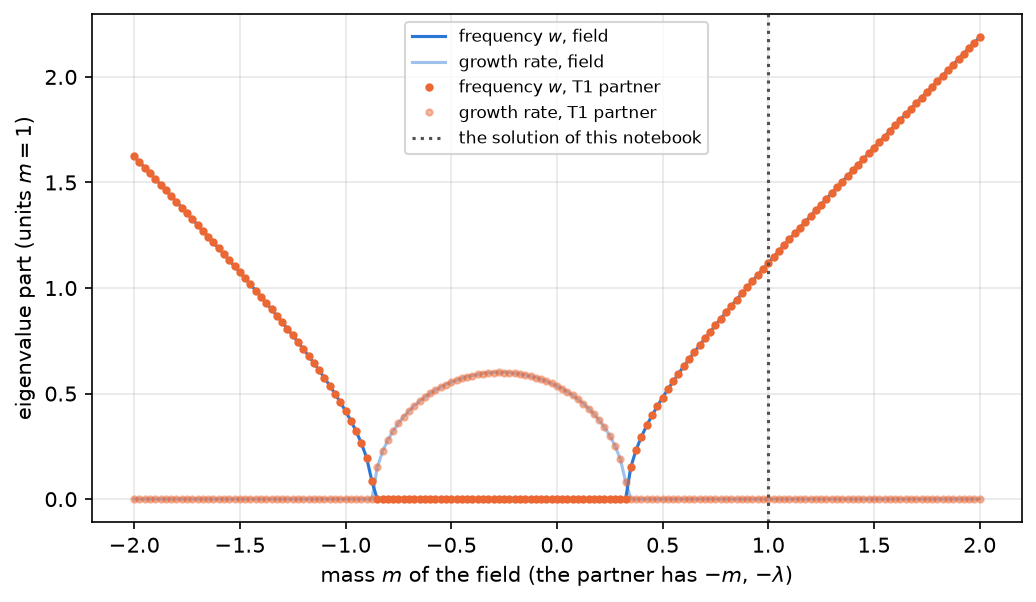

Figure 18c.5 saved as Revision/textbook/figures/18c_5_family_spectrum.png


In [15]:
fig, ax = plt.subplots(figsize=(8.0, 4.4))
for label, colour, style in (("field", "#2a78d6", "-"),
                             ("T1 partner", "#eb6834", "o")):
    rows = family[label]
    kw = {"markersize": 3} if style == "o" else {}
    ax.plot(masses, rows.imag.max(axis=1), style, color=colour,
            label=f"frequency $w$, {label}", **kw)
    ax.plot(masses, rows.real.max(axis=1), style, color=colour, alpha=0.45,
            label=f"growth rate, {label}", **kw)
ax.axvline(m, color="#52514e", linestyle=":", label="the solution of this notebook")
ax.set_xlabel("mass $m$ of the field (the partner has $-m$, $-\\lambda$)")
ax.set_ylabel("eigenvalue part (units $m = 1$)")
ax.legend(fontsize=8, loc="upper center")
save_figure(fig, "family_spectrum",
            "The spectrum of the evolution generator of the homogeneous solutions, "
            "against the mass $m$ (horizontal axis) at the fixed coupling "
            "$\\lambda = 0.3$ and scalar $S$ of this notebook, $H = 0.2$. Dark "
            "curves: the oscillation frequency $w$, the largest imaginary part of "
            "the eigenvalues; light curves: the growth rate, the largest real part. "
            "Lines: the field with $(m, \\lambda)$; dots: its T1 partner with "
            "$(-m, -\\lambda)$. They coincide everywhere. Inside the window "
            "$|m + \\lambda S| < 3H$ the frequency is zero and the solutions grow; "
            "outside it they oscillate. The dotted line marks the solution "
            "plotted above.")

## 11. Plane waves in flat 4+4 space: the quantum reading Q

The next cell builds the one-particle matrix $h_m(k)$ of the Revision pairing
record and checks, numerically: $h_m^2 = w^2I_{16}$ with $w^2 = m^2 + k_1^2 + k_2^2
+ k_3^2 + k_8^2 - k_5^2 - k_6^2 - k_7^2$ (for 50 random momenta); the maps
$\Gamma h_m(k)\Gamma = h_{-m}(k)$ and $\gamma^{(x_8)}h_m(k)\gamma^{(x_8)} =
h_{-m}(R_8k)$, where $R_8k$ reverses $k_8$; and it reproduces the eight samples
of the data table `one_particle_flat` of the pairing record: the frequency $w$,
the dimension of the eigenspaces of $+w$ and $-w$, and the *Krein inertia* of
each (the numbers of positive and negative eigenvalues of the $8 \times 8$ matrix
$V^\dagger BV$, where the 8 columns of $V$ span the eigenspace).

In [16]:
def h_matrix(mass, k):
    """h_m(k) = -i m gamma^(x4) - gamma^(x4) sum_(a != 4) k_a gamma^(a)."""
    out = -1j * mass * gamma[4]
    for a in (1, 2, 3, 5, 6, 7, 8):
        out = out - k[a - 1] * gamma[4] @ gamma[a]
    return out


def w_squared(mass, k):
    return mass ** 2 + sum(k[a - 1] ** 2 for a in (1, 2, 3, 8)) - sum(
        k[a - 1] ** 2 for a in (5, 6, 7))


def eigenspace(Mx, value, tol=1e-9):
    """Orthonormal columns spanning the null space of Mx - value I."""
    _, sv, vh = np.linalg.svd(Mx - value * I16)
    return vh[sv < tol].conj().T


def inertia(V):
    """(positive, negative) eigenvalue counts of V^dagger B V."""
    ev = np.linalg.eigvalsh(V.conj().T @ B @ V)
    return int((ev > 1e-9).sum()), int((ev < -1e-9).sum())


R8 = np.array([1, 1, 1, 1, 1, 1, 1, -1], dtype=float)
rand = np.random.default_rng(7)
square_ok = maps_ok = True
for _ in range(50):
    k, mv = rand.normal(size=8), rand.normal()
    h = h_matrix(mv, k)
    square_ok = square_ok and np.allclose(h @ h, w_squared(mv, k) * I16, atol=1e-12)
    maps_ok = (maps_ok and np.allclose(Gamma @ h @ Gamma, h_matrix(-mv, k))
               and np.allclose(gamma[8] @ h @ gamma[8], h_matrix(-mv, R8 * k)))
samples = read_json(THEORY)["data"]["one_particle_flat"]["samples"]
rows_ok = True
for row in samples:
    k = np.array(row["k"], dtype=float)
    w = float(sp.sympify(row["w"].replace("Sqrt[", "sqrt(").replace("]", ")")))
    h = h_matrix(row["m"], k)
    Vp, Vn = eigenspace(h, w), eigenspace(h, -w)
    mine = (np.isclose(np.sqrt(w_squared(row["m"], k)), w), Vp.shape[1],
            Vn.shape[1], inertia(Vp), inertia(Vn))
    rows_ok = rows_ok and mine == (True, row["dim_plus_w"], row["dim_minus_w"],
                                   tuple(row["B_inertia_plus_w"]),
                                   tuple(row["B_inertia_minus_w"]))
    (pp, pn), (qp, qn) = inertia(Vp), inertia(Vn)
    say(f"m = {row['m']:+d}, k = {row['k']}: w = {w:.6f}, dimensions "
        f"{Vp.shape[1]} and {Vn.shape[1]}, Krein inertia ({pp},{pn}) and "
        f"({qp},{qn})")
reproduces(square_ok and maps_ok,
           "h_m^2 = w^2 I16; Gamma h_m Gamma = h_-m; gamma^(x8) h_m gamma^(x8) = "
           "h_-m(R8 k)", (WL, ["Q_one_particle_flat_dispersion", "Q_one_particle_maps"]),
           (PY, ["Q.one_particle_maps"]))
reproduces(rows_ok and len(samples) == 8,
           "the eight recorded samples: w, dimensions 8 and 8, Krein inertia (4,4)",
           (WL, ["Q_one_particle_Krein_signatures"]),
           (PY, ["compare.theory.one_particle", "Q.one_particle_Krein_inertia_proof"]))

m = +2, k = [1, 2, 0, 0, 0, 0, 0, 4]: w = 5.000000, dimensions 8 and 8, Krein inertia
    (4,4) and (4,4)
m = -2, k = [1, 2, 0, 0, 0, 0, 0, 4]: w = 5.000000, dimensions 8 and 8, Krein inertia
    (4,4) and (4,4)
m = +3, k = [0, 0, 0, 0, 0, 0, 0, 0]: w = 3.000000, dimensions 8 and 8, Krein inertia
    (4,4) and (4,4)
m = -3, k = [0, 0, 0, 0, 0, 0, 0, 0]: w = 3.000000, dimensions 8 and 8, Krein inertia
    (4,4) and (4,4)
m = +1, k = [1, 0, 0, 0, 0, 0, 0, 0]: w = 1.414214, dimensions 8 and 8, Krein inertia
    (4,4) and (4,4)
m = -1, k = [1, 0, 0, 0, 0, 0, 0, 0]: w = 1.414214, dimensions 8 and 8, Krein inertia
    (4,4) and (4,4)
m = +2, k = [0, 0, 0, 0, 1, 0, 0, 0]: w = 1.732051, dimensions 8 and 8, Krein inertia
    (4,4) and (4,4)
m = -2, k = [0, 0, 0, 0, 1, 0, 0, 0]: w = 1.732051, dimensions 8 and 8, Krein inertia
    (4,4) and (4,4)
PASS h_m^2 = w^2 I16; Gamma h_m Gamma = h_-m; gamma^(x8) h_m gamma^(x8) = h_-m(R8 k)
     reproduces Revision/pairing/reports/wolfram-pairing.json, chec

The next cell checks the three recorded samples with imaginary or zero frequency
(an extra-time momentum $k_5$ larger than the mass): $m = 1$ with $k_5 = 2$
($w^2 = -3$), with $k_1 = 1, k_5 = 2$ ($w^2 = -2$), and with $k_5 = 1$
($w^2 = 0$). For an imaginary $w$ each eigenspace has dimension 8 and the Krein
form $V^\dagger BV$ is ZERO on it (*Krein-neutral*); for $w = 0$ the matrix $h$
has the null space of dimension 8, also Krein-neutral, and $h^2 = 0$.

In [17]:
neutral_ok = True
for k in ([0, 0, 0, 0, 2, 0, 0, 0], [1, 0, 0, 0, 2, 0, 0, 0],
          [0, 0, 0, 0, 1, 0, 0, 0]):
    k = np.array(k, dtype=float)
    h, w2 = h_matrix(1.0, k), w_squared(1.0, k)
    if w2 == 0:
        spaces = [eigenspace(h, 0.0)]
        neutral_ok = neutral_ok and np.allclose(h @ h, 0.0)
    else:
        w = 1j * np.sqrt(-w2)
        spaces = [eigenspace(h, w), eigenspace(h, -w)]
    dims = [V.shape[1] for V in spaces]
    largest = max(np.abs(V.conj().T @ B @ V).max() for V in spaces)
    neutral_ok = neutral_ok and all(dim == 8 for dim in dims) and largest < 1e-9
    say(f"k = {k.astype(int).tolist()}: w^2 = {w2:+.0f}, eigenspace dimensions "
        f"{dims}, Krein form zero on them: {largest < 1e-9}")
reproduces(neutral_ok, "imaginary and zero frequencies: eigenspaces of dimension 8 "
           "are Krein-neutral",
           (PY, ["Q.one_particle_complex_frequency_Krein_neutral"]),
           (WL, ["Q_one_particle_complex_and_zero_frequencies_Krein_neutral"]))

k = [0, 0, 0, 0, 2, 0, 0, 0]: w^2 = -3, eigenspace dimensions [8, 8], Krein form zero on
    them: True
k = [1, 0, 0, 0, 2, 0, 0, 0]: w^2 = -2, eigenspace dimensions [8, 8], Krein form zero on
    them: True
k = [0, 0, 0, 0, 1, 0, 0, 0]: w^2 = +0, eigenspace dimensions [8], Krein form zero on
    them: True
PASS imaginary and zero frequencies: eigenspaces of dimension 8 are Krein-neutral
     reproduces Revision/pairing/reports/python-pairing.json, check
    Q.one_particle_complex_frequency_Krein_neutral; Revision/pairing/reports/wolfram-
    pairing.json, check Q_one_particle_complex_and_zero_frequencies_Krein_neutral


The next cell draws the mapped spectra of plane waves: the eigenvalues of
$h_m(k)$ for the mass $m = 1$ (lines) and of $h_{-m}(k)$ (dots), against a
3-space momentum $k_1$ (left) and against an extra-time momentum $k_5$ (right).
The cell first checks that the two sets of 16 eigenvalues agree at every momentum
(away from the single point $k_5 = 1$, where $w = 0$ and the eigenvalues of a
matrix with $h^2 = 0$ cannot be computed accurately in floating point).

PASS the plane-wave spectra of the masses +1 and -1 are equal


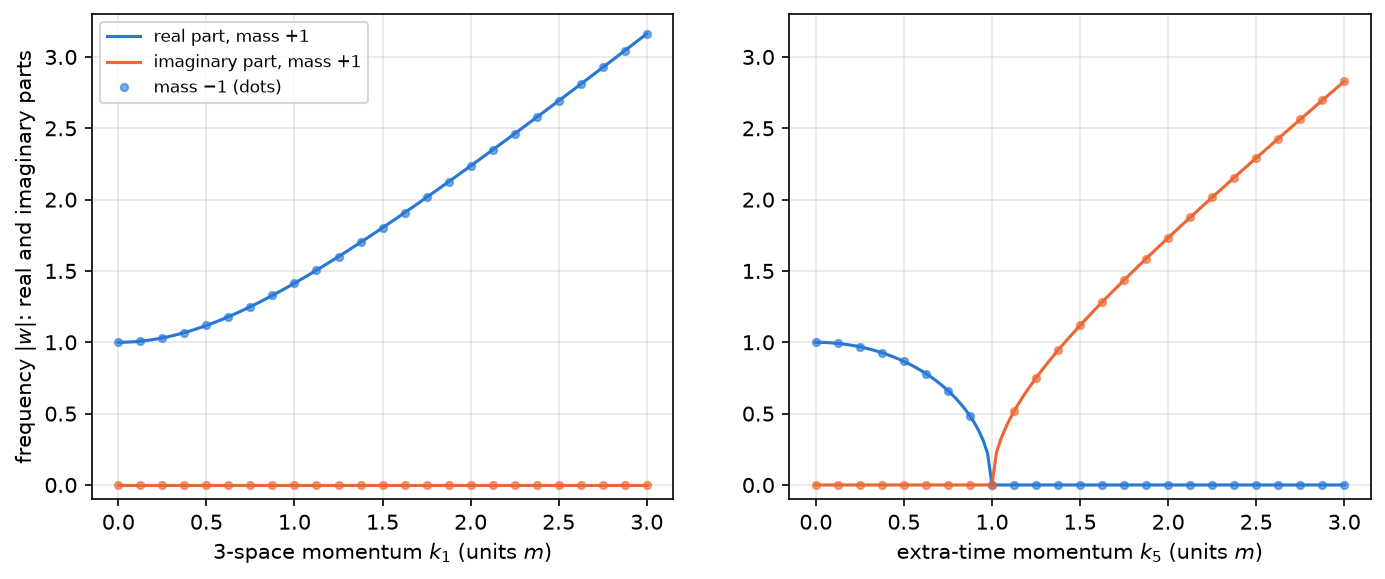

Figure 18c.6 saved as Revision/textbook/figures/18c_6_flat_dispersion.png


In [18]:
ks = np.linspace(0.0, 3.0, 121)
curves = {}
for label, mass in (("plus", 1.0), ("minus", -1.0)):
    for axis in (1, 5):
        rows = []
        for kv in ks:
            k = np.zeros(8)
            k[axis - 1] = kv
            rows.append(spectrum(h_matrix(mass, k)))
        curves[label, axis] = np.array(rows)
away = np.abs(ks - 1.0) > 0.05
equal = max(np.abs(curves["plus", axis][away] - curves["minus", axis][away]).max()
            for axis in (1, 5))
check(equal < 1e-6, "the plane-wave spectra of the masses +1 and -1 are equal")
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))
for ax, axis, name in ((axes[0], 1, "3-space momentum $k_1$"),
                       (axes[1], 5, "extra-time momentum $k_5$")):
    ax.plot(ks, np.sqrt(np.clip(1.0 + (ks ** 2 if axis == 1 else -ks ** 2), 0, None)),
            color="#2a78d6", label="real part, mass $+1$")
    ax.plot(ks, np.sqrt(np.clip(-1.0 + (ks ** 2 if axis == 5 else -ks ** 2), 0,
                                None)), color="#eb6834",
            label="imaginary part, mass $+1$")
    dots = curves["minus", axis]
    ax.plot(ks[::5], np.abs(dots.real).max(axis=1)[::5], "o", color="#2a78d6",
            markersize=3.5, alpha=0.6, label="mass $-1$ (dots)")
    ax.plot(ks[::5], np.abs(dots.imag).max(axis=1)[::5], "o", color="#eb6834",
            markersize=3.5, alpha=0.6)
    ax.set_xlabel(name + " (units $m$)")
    ax.set_ylim(-0.1, 3.3)
axes[0].set_ylabel("frequency $|w|$: real and imaginary parts")
axes[0].legend(fontsize=8, loc="upper left")
save_figure(fig, "flat_dispersion",
            "Mapped spectra of plane waves in flat 4+4 space: the frequencies, the "
            "eigenvalues of the one-particle matrix $h_m(k)$, for the mass $+1$ "
            "(lines) and $-1$ (dots), against a 3-space momentum $k_1$ (left) and "
            "an extra-time momentum $k_5$ (right), in units of the mass. Blue: "
            "the real part $\\sqrt{1 + k_1^2}$ or $\\sqrt{1 - k_5^2}$; orange: the "
            "imaginary part, which appears when the extra-time momentum exceeds the "
            "mass (a growing mode). Each value is 8-fold, with both signs. The "
            "dots lie on the lines: the universes of mass $+m$ and $-m$ have the "
            "same one-particle spectrum, because $\\Gamma h_m\\Gamma = h_{-m}$.")

The next cell looks at the eigenvectors themselves, at the first recorded sample
($m = 2$, $k = (1, 2, 0, 0, 0, 0, 0, 4)$, $w = 5$). In each eigenspace it chooses
8 columns $u$ with Krein norms $u^\dagger Bu = \pm1$ (the eigenvectors of
$V^\dagger BV$, rescaled), 16 in all. Then: $\Gamma u$ is an eigenvector of
$h_{-m}(k)$ with the same frequency and the OPPOSITE Krein norm (Lemma 4,
$\Gamma B\Gamma = -B$); $\gamma^{(x_8)}u$ is an eigenvector of $h_{-m}(R_8k)$
with the same frequency and the SAME Krein norm ($\gamma^{(x_8)}B
\gamma^{(x_8)} = B$).

In [19]:
row = samples[0]
k = np.array(row["k"], dtype=float)
w = 5.0
h = h_matrix(row["m"], k)
columns, freqs = [], []
for value in (w, -w):
    V = eigenspace(h, value)
    ev, U = np.linalg.eigh(V.conj().T @ B @ V)  # diagonalise the Krein form
    for j in np.argsort(-ev):  # positive norms first
        u = V @ U[:, j] / np.sqrt(abs(ev[j]))  # Krein norm +1 or -1
        columns.append(u)
        freqs.append(value)
norms = np.array([(u.conj() @ B @ u).real for u in columns])
norms_G = np.array([((Gamma @ u).conj() @ B @ (Gamma @ u)).real for u in columns])
norms_8 = np.array([((gamma[8] @ u).conj() @ B @ (gamma[8] @ u)).real
                    for u in columns])
eig_G = all(np.allclose(h_matrix(-row["m"], k) @ (Gamma @ u), f * (Gamma @ u))
            for u, f in zip(columns, freqs))
eig_8 = all(np.allclose(h_matrix(-row["m"], R8 * k) @ (gamma[8] @ u),
                        f * (gamma[8] @ u)) for u, f in zip(columns, freqs))
say("Krein norms of the 16 columns: " + " ".join(f"{x:+.0f}" for x in norms))
reproduces(eig_G and eig_8 and np.allclose(norms_G, -norms)
           and np.allclose(norms_8, norms) and int((norms > 0).sum()) == 8,
           "Gamma u: eigenvector of h_-m, Krein norm reversed; gamma^(x8) u: kept",
           (WL, ["Q_Krein_metric_of_images"]),
           (PY, ["Q.image_krein_metric", "Q.T2_image_keeps_B"]))

Krein norms of the 16 columns: +1 +1 +1 +1 -1 -1 -1 -1 +1 +1 +1 +1 -1 -1 -1 -1
PASS Gamma u: eigenvector of h_-m, Krein norm reversed; gamma^(x8) u: kept
     reproduces Revision/pairing/reports/wolfram-pairing.json, check
    Q_Krein_metric_of_images; Revision/pairing/reports/python-pairing.json, check
    Q.image_krein_metric, Q.T2_image_keeps_B


The next cell draws the 16 Krein norms and those of the two images as bars.

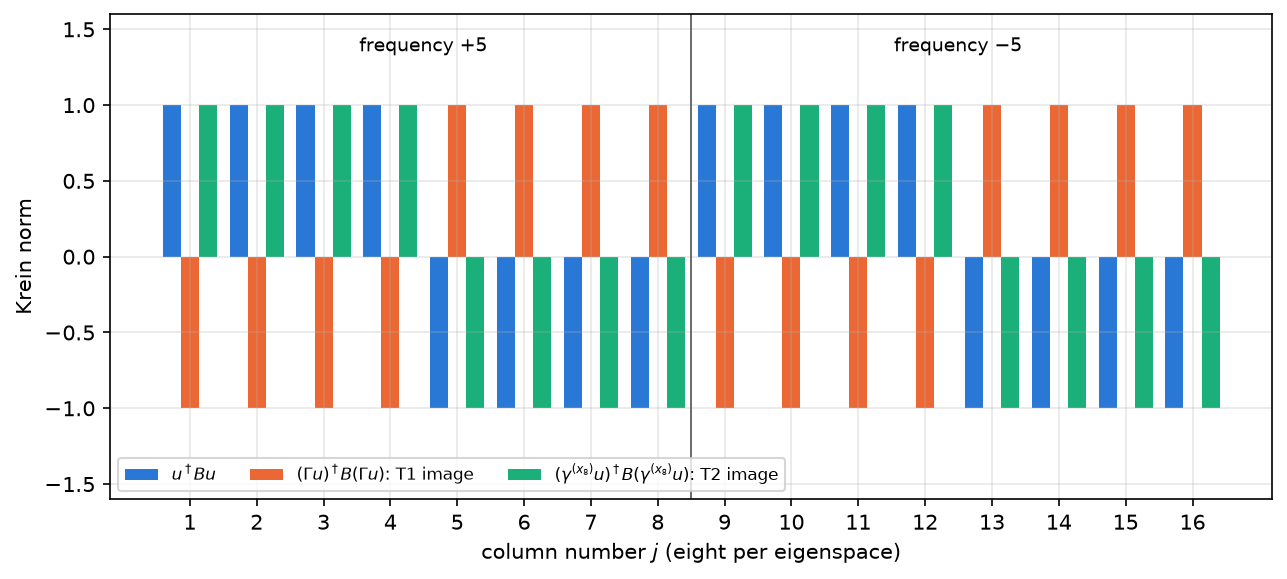

Figure 18c.7 saved as Revision/textbook/figures/18c_7_krein_norms.png


In [20]:
fig, ax = plt.subplots(figsize=(10.0, 4.2))
idx = np.arange(16)
ax.bar(idx - 0.27, norms, width=0.27, color="#2a78d6", label="$u^\\dagger Bu$")
ax.bar(idx, norms_G, width=0.27, color="#eb6834",
       label="$(\\Gamma u)^\\dagger B(\\Gamma u)$: T1 image")
ax.bar(idx + 0.27, norms_8, width=0.27, color="#1baf7a",
       label="$(\\gamma^{(x_8)}u)^\\dagger B(\\gamma^{(x_8)}u)$: T2 image")
ax.axvline(7.5, color="#52514e", linewidth=0.8)
ax.text(3.5, 1.35, "frequency $+5$", ha="center", fontsize=9)
ax.text(11.5, 1.35, "frequency $-5$", ha="center", fontsize=9)
ax.set_xticks(idx, [str(j + 1) for j in idx])
ax.set_xlabel("column number $j$ (eight per eigenspace)")
ax.set_ylabel("Krein norm")
ax.set_ylim(-1.6, 1.6)
ax.legend(fontsize=8, loc="lower left", ncol=3)
save_figure(fig, "krein_norms",
            "Krein norms of plane-wave eigenvectors and of their images, for the "
            "recorded sample $m = 2$, $k = (1, 2, 0, 0, 0, 0, 0, 4)$, frequency "
            "$w = \\pm5$. Horizontal axis: the 16 eigenvector columns $u$, eight "
            "for $+5$ and eight for $-5$; vertical axis: the Krein norm. Blue: "
            "$u^\\dagger Bu$, four $+1$ and four $-1$ in each eigenspace (Krein "
            "inertia (4,4)). Orange: the chirality image $\\Gamma u$, an "
            "eigenvector of the mass $-m$ with every norm reversed. Green: the "
            "mirror image $\\gamma^{(x_8)}u$, an eigenvector of the mass $-m$ with "
            "every norm kept. This is the quantum reading Q at the level of single "
            "modes.")

## 12. The last check

The last cell checks that the seven figure files exist and prints the number of
checks that passed.

In [21]:
figure_names = ["rk4_convergence", "partner_components", "t1_pair_densities",
                "t2_mirror_densities", "family_spectrum", "flat_dispersion",
                "krein_norms"]
paths = [output_file(f"{FIGURE_FOLDER}/18c_{k}_{name}.png")
         for k, name in enumerate(figure_names, 1)]
check(all(path.is_file() for path in paths),
      "every figure file of this notebook exists")
all_checks_passed()

PASS every figure file of this notebook exists
ALL 21 CHECKS PASSED (notebook 18c)


## 13. What this notebook showed

- COMPUTED (RK4, fourth order measured, checked against the exact solution of the
  Revision theory record): a homogeneous solution of dirac16complex00 in the
  author's metric with $m = 1$, $H = 0.2$, $\lambda = 0.3$ (illustrative values),
  with constant $S$, oscillating at the frequency $w = \sqrt{(m + \lambda S)^2 -
  9H^2}$, and with the charge flowing along the hidden direction exactly as the
  conservation law requires.
- COMPUTED, theorem T1: the theory with $(-m, -\lambda)$, solved on its own from
  $\Gamma\Psi(0)$, gives $\Gamma\Psi(x_4)$ at all times; its charge density,
  current and all 36 components of $T_{\mu\nu}$ along the deflating history
  $a_4 = AHx_4$ are exactly opposite, so the pair sums to zero at every time (as
  classical bilinears).
- COMPUTED, theorem T2: the theory with $(-m, \lambda)$ on the mirror patch, solved
  on its own from $\gamma^{(x_8)}\Psi(0)$, gives $\gamma^{(x_8)}\Psi(x_4)$; $S$ is
  opposite, the charge density and the energy density are EQUAL, the other
  components are pulled back by the reflection of $x_8$.
- COMPUTED and PROVED (similar matrices): the field and its partners have equal
  spectra; for plane waves in flat 4+4 space the masses $+m$ and $-m$ have the
  same frequencies, every real frequency has Krein inertia (4,4) in the eight
  recorded samples, the imaginary and zero frequencies are Krein-neutral, and
  $\Gamma$ reverses every Krein norm while $\gamma^{(x_8)}$ keeps it (the quantum
  reading Q).
- ASSUMED: the mirror patch glued at the degenerate brane (Z2 construction); the
  gravitational field is a fixed background.
- NOT shown: any process that creates a universe or a pair. The partners here are
  solutions of OTHER parameter sets, computed from the first one; nothing in these
  equations makes them appear.